In [1]:
!pip install fastbook

In [2]:
import fastbook
fastbook.setup_book()

In [3]:
from fastbook import *

In [4]:
path = untar_data(URLs.MNIST_SAMPLE)

In [5]:
train_3 = torch.stack([tensor(Image.open(o)) for o in (path/'train'/'3').ls().sorted()]).float() / 255
train_7 = torch.stack([tensor(Image.open(o)) for o in (path/'train'/'7').ls().sorted()]).float() / 255
valid_3 = torch.stack([tensor(Image.open(o)) for o in (path/'valid'/'3').ls().sorted()]).float() / 255
valid_7 = torch.stack([tensor(Image.open(o)) for o in (path/'valid'/'7').ls().sorted()]).float() / 255

# Build classifier using pixel similarlity

In [6]:
mean3 = train_3.mean(0)
mean7 = train_7.mean(0)

In [7]:
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))

In [8]:
def is_3(x): return mnist_distance(x,mean3) < mnist_distance(x,mean7)

In [9]:
accuracy_3s =      is_3(valid_3).float() .mean()
accuracy_7s = (1 - is_3(valid_7).float()).mean()

accuracy_3s,accuracy_7s,(accuracy_3s+accuracy_7s)/2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

# Build 3/7 Learner

In [10]:
train_x = torch.cat([train_3, train_7]).view(-1, 28*28)
train_y = tensor([1]*len(train_3) + [0]*len(train_7)).unsqueeze(1)
dset = list(zip(train_x,train_y))

In [11]:
valid_x = torch.cat([valid_3, valid_7]).view(-1, 28*28)
valid_y = tensor([1]*len(valid_3) + [0]*len(valid_7)).unsqueeze(1)
valid_dset = list(zip(valid_x,valid_y))

In [12]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [13]:
weights = init_params((28*28,1))

In [14]:
bias = init_params(1)

In [15]:
def linear1(xb): return xb@weights + bias

In [16]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [17]:
weights = init_params((28*28,1))
bias = init_params(1)

In [18]:
dl = DataLoader(dset, batch_size=256)
xb,yb = first(dl)
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

In [19]:
valid_dl = DataLoader(valid_dset, batch_size=256)

In [20]:
def calc_grad(xb, yb, model):
    preds = model(xb)
    loss = mnist_loss(preds, yb)
    loss.backward()

In [21]:
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

In [22]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [23]:
def validate_epoch(model):
    accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
    return round(torch.stack(accs).mean().item(), 4)

In [24]:
lr = 1.
params = weights,bias
train_epoch(linear1, lr, params)
validate_epoch(linear1)

0.7251

In [25]:
for i in range(20):
    train_epoch(linear1, lr, params)
    print(validate_epoch(linear1), end=' ')

0.8569 0.9096 0.9296 0.9399 0.9468 0.9546 0.957 0.9629 0.9648 0.9663 0.9673 0.9682 0.9726 0.9726 0.9726 0.9731 0.9736 0.9741 0.9741 0.9751 

# Build 3/7 Learner as train_model function with optimizer

In [26]:
linear_model = nn.Linear(28*28,1)

In [27]:
class BasicOptim:
    def __init__(self,params,lr): self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [28]:
opt = BasicOptim(linear_model.parameters(), lr)

In [29]:
def train_epoch(model):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        opt.step()
        opt.zero_grad()

In [30]:
def train_model(model, epochs):
    for i in range(epochs):
        train_epoch(model)
        print(validate_epoch(model), end=' ')

In [31]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(), lr)
train_model(linear_model, 20)

0.4932 0.8706 0.8276 0.9102 0.9331 0.9458 0.9551 0.9629 0.9658 0.9673 0.9687 0.9712 0.9741 0.9751 0.9761 0.9761 0.9775 0.978 0.9785 0.9785 

# Implement train_model as a Learner with a single-layer neural net

In [32]:
dls = DataLoaders(dl, valid_dl)

In [33]:
learn = Learner(dls, nn.Linear(28*28,1), opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [34]:
learn.fit(10, lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.636884,0.503483,0.495584,00:00
1,0.525323,0.197635,0.830716,00:00
2,0.193055,0.175610,0.842493,00:00
3,0.084568,0.105104,0.911678,00:00
4,0.044592,0.077108,0.933268,00:00
5,0.028991,0.061910,0.947007,00:00
6,0.022591,0.052414,0.954858,00:00
7,0.019752,0.046097,0.962218,00:00
8,0.018318,0.041659,0.966143,00:00
9,0.017461,0.038389,0.968106,00:00


# Implement train_model as a Learner with a multi--layer neural net

In [35]:
'''def simple_net(xb): 
    res = xb@w1 + b1
    res = res.max(tensor(0.0))
    res = res@w2 + b2
    return res

w1 = init_params((28*28,30))
b1 = init_params(30)
w2 = init_params((30,1))
b2 = init_params(1)
'''

'def simple_net(xb): \n    res = xb@w1 + b1\n    res = res.max(tensor(0.0))\n    res = res@w2 + b2\n    return res\n\nw1 = init_params((28*28,30))\nb1 = init_params(30)\nw2 = init_params((30,1))\nb2 = init_params(1)\n'

In [36]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

In [37]:
learn = Learner(dls, simple_net, opt_func=SGD,
                loss_func=mnist_loss, metrics=batch_accuracy)

In [38]:
learn.fit(40, 0.1)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.262445,0.409559,0.505888,00:00
1,0.128206,0.209642,0.830716,00:00
2,0.073543,0.108963,0.921982,00:00
3,0.049928,0.075197,0.942100,00:00
4,0.038751,0.059383,0.957311,00:00
5,0.032904,0.050371,0.962709,00:00
6,0.029462,0.044643,0.967125,00:00
7,0.027177,0.040708,0.967615,00:00
8,0.025506,0.037834,0.969087,00:00
9,0.024199,0.035635,0.970559,00:00


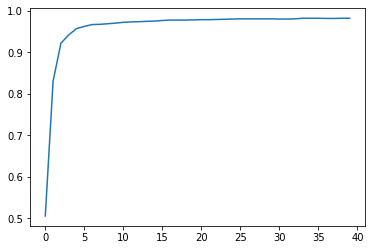

In [39]:
plt.plot(L(learn.recorder.values).itemgot(2));

In [40]:
learn.recorder.values[-1][2]

0.98233562707901

# Impelment Learner from scratch

In [51]:
class Learner:
    def __init__(self, dls, model, opt_func, loss_func, metrics):
        self.lr = 0.1
        self.dl = dls
        self.model = model
        self.opt_func = opt_func
        self.loss_func = loss_func
        self.metrics = metrics
        
    def fit(self, epochs, lr):
        learning_rate = self.lr
        if lr is not None:
            learning_rate = lr
        for i in range(epochs):
            self.train_epoch(learning_rate)
            print(self.validate_epoch(), end=' ')
            
    def train_epoch(self, lr):
        train_dl = first(self.dl)
        opt = self.opt_func(self.model.parameters(), lr=lr)
        for xb,yb in train_dl:
            self.calc_grad(xb, yb)
            opt.step()
            opt.zero_grad()
            
    def calc_grad(self, xb, yb):
        preds = self.model(xb)
        loss = self.loss_func(preds, yb)
        loss.backward()
        

    def validate_epoch(self):
        valid_dl = self.dl[1]
        accs = [self.metrics(self.model(xb), yb) for xb,yb in valid_dl]
        return round(torch.stack(accs).mean().item(), 4)


In [42]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)
opt = SGD(linear_model.parameters(), lr)
learn = Learner(dls, simple_net, opt_func=SGD, loss_func=mnist_loss, metrics=batch_accuracy)

In [43]:
learn.fit(40, 0.1)

0.5112 0.7817 0.9126 0.9395 0.9546 0.9638 0.9658 0.9663 0.9678 0.9702 0.9707 0.9726 0.9741 0.9751 0.9751 0.9765 0.977 0.977 0.9775 0.978 0.9785 0.9785 0.9795 0.9804 0.9804 0.9804 0.9804 0.9804 0.9809 0.9809 0.9809 0.9824 0.9824 0.9824 0.9824 0.9829 0.9829 0.9824 0.9829 0.9829 

# Implement multi-label learner for MNIST

In [44]:
path = untar_data(URLs.MNIST)

In [45]:
(path/'training').ls()

(#10) [Path('/root/.fastai/data/mnist_png/training/9'),Path('/root/.fastai/data/mnist_png/training/3'),Path('/root/.fastai/data/mnist_png/training/6'),Path('/root/.fastai/data/mnist_png/training/0'),Path('/root/.fastai/data/mnist_png/training/7'),Path('/root/.fastai/data/mnist_png/training/2'),Path('/root/.fastai/data/mnist_png/training/4'),Path('/root/.fastai/data/mnist_png/training/8'),Path('/root/.fastai/data/mnist_png/training/5'),Path('/root/.fastai/data/mnist_png/training/1')]

In [46]:
def load_mnist_split(path, split):
    images = []
    labels = []

    for digit in range(10):
        digit_images = torch.stack([
            tensor(Image.open(file))
            for file in (path / split / str(digit)).ls().sorted()
        ]).float() / 255

        images.append(digit_images)

        # Create one label per image: 0, 1, 2, ..., or 9
        labels.append(
            torch.full(
                (len(digit_images),),
                digit,
                dtype=torch.long
            )
        )
        print(f"Digit: {digit}, Count: {len(digit_images)}")
    x = torch.cat(images).view(-1, 28 * 28)
    y = torch.cat(labels)

    return x, y

train_x, train_y = load_mnist_split(path, 'training')
valid_x, valid_y = load_mnist_split(path, 'testing')

Digit: 0, Count: 5923
Digit: 1, Count: 6742
Digit: 2, Count: 5958
Digit: 3, Count: 6131
Digit: 4, Count: 5842
Digit: 5, Count: 5421
Digit: 6, Count: 5918
Digit: 7, Count: 6265
Digit: 8, Count: 5851
Digit: 9, Count: 5949
Digit: 0, Count: 980
Digit: 1, Count: 1135
Digit: 2, Count: 1032
Digit: 3, Count: 1010
Digit: 4, Count: 982
Digit: 5, Count: 892
Digit: 6, Count: 958
Digit: 7, Count: 1028
Digit: 8, Count: 974
Digit: 9, Count: 1009


In [47]:
train_x.shape, train_y.shape, valid_x.shape, valid_y.shape

(torch.Size([60000, 784]),
 torch.Size([60000]),
 torch.Size([10000, 784]),
 torch.Size([10000]))

In [93]:
train_dset = list(zip(train_x, train_y))
dl = DataLoader(train_dset, batch_size=256)
valid_dset = list(zip(valid_x,valid_y))
valid_dl = DataLoader(valid_dset, batch_size=256)
dls = DataLoaders(dl, valid_dl)

In [95]:
def mnist_loss(predictions, targets):
    #loss = F.cross_entropy(predictions, targets.squeeze())
    #return loss
    return F.cross_entropy(predictions, targets)

def batch_accuracy(predictions, targets):
    #predictions = F.softmax(xb, dim=1)
    predicted_digits = predictions.argmax(dim=1)
    return (predicted_digits == targets).float().mean()

simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,10)
)
opt = SGD(linear_model.parameters(), lr)
learn = Learner(dls, simple_net, opt_func=SGD, loss_func=mnist_loss, metrics=batch_accuracy)

In [96]:
learn.fit(40, 2e-3)

0.2021 0.2657 0.3487 0.434 0.4829 0.5065 0.5311 0.559 0.5868 0.6127 0.6358 0.6552 0.6684 0.6826 0.696 0.7073 0.7146 0.7217 0.7295 0.7363 0.744 0.7502 0.7574 0.7652 0.7704 0.7757 0.7816 0.7871 0.7929 0.7968 0.8013 0.8052 0.809 0.8132 0.8167 0.8197 0.8233 0.8268 0.8303 0.8328 